In [52]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers, callbacks, utils
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from collections import Counter

In [53]:
df=pd.read_csv("cleaned_dataset_taiwan_2months.csv")
df.head()

,date,sitename,county,aqi,status,so2,co,o3,pm10,pm2.5,no2,nox,no,siteid
0,2024-08-31 23:00:00,Hukou,Hsinchu County,62.0,Moderate,0.9,0.17,35.0,18.0,17.0,2.3,2.6,0.3,22
1,2024-08-31 23:00:00,Zhongming,Taichung City,50.0,Good,1.6,0.32,27.9,27.0,14.0,7.6,9.3,1.6,31
2,2024-08-31 23:00:00,Zhudong,Hsinchu County,45.0,Good,0.4,0.17,25.1,21.0,13.0,2.9,4.1,1.1,23
3,2024-08-31 23:00:00,Hsinchu,Hsinchu City,42.0,Good,0.8,0.20,30.0,19.0,10.0,4.0,4.8,0.7,24
4,2024-08-31 23:00:00,Toufen,Miaoli County,50.0,Good,1.0,0.16,33.5,18.0,14.0,1.8,3.1,1.2,25


In [54]:
features = ['so2', 'co', 'o3', 'pm10', 'pm2.5', 'no2', 'nox', 'no']
X = df[features]
y = df['status']

In [55]:
le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())
num_classes = len(le.classes_)
#y_encoded =utils.to_categorical(y_encoded, num_classes=num_classes)

In [56]:
X_train,X_test,y_train,y_test=train_test_split(X,y_encoded,test_size=0.2,shuffle=True)

In [57]:
smote = SMOTE( random_state=20)
X_train_resampled,y_train_resampled = smote.fit_resample(X_train, y_train)

In [58]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

In [59]:
model = tf.keras.Sequential([
# Input shape: (Time Steps, Features)
    layers.Input(shape=(8,)), 
    
    
    # first Dense layer
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Second Dense layer
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # third Dense layer
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # third Dense layer
    layers.Dense(32),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

In [60]:
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='best_model_svm_classifier.keras', monitor='val_accuracy', save_best_only=True),
    reduce_lr
]

In [61]:
model.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_scaled, y_train_resampled, epochs=100, batch_size=128,validation_split=0.2,callbacks=my_callbacks,shuffle=True)

Epoch 1/100
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7809 - loss: 0.5181 - val_accuracy: 0.7864 - val_loss: 0.5514 - learning_rate: 5.0000e-04
Epoch 2/100
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8172 - loss: 0.4365 - val_accuracy: 0.8645 - val_loss: 0.3894 - learning_rate: 5.0000e-04
Epoch 3/100
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8304 - loss: 0.4079 - val_accuracy: 0.8811 - val_loss: 0.3362 - learning_rate: 5.0000e-04
Epoch 4/100
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8410 - loss: 0.3871 - val_accuracy: 0.9200 - val_loss: 0.2880 - learning_rate: 5.0000e-04
Epoch 5/100
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8462 - loss: 0.3744 - val_accuracy: 0.9617 - val_loss: 0.2037 - learning_rate: 5.0000e-04
Epoch 6/100
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8517 - loss: 0.3641 - val_accuracy: 0.9676 - val_loss: 0.1687 - learning_rate: 5.0000e-04
Epoch 7/100
 584/1724 ━━━━━━━━━━━━━━━━━━━━ 

KeyboardInterrupt: 

In [62]:
best_model=tf.keras.models.load_model("best_model_svm_classifier.keras")
best_model.build(input_shape=(None,8))


# Reconstruct the feature extractor by defining an explicit input layer
input_layer = layers.Input(shape=(8,))
x = input_layer

for layer in best_model.layers[:-2]: 
    x = layer(x)

feature_extractor = models.Model(inputs=input_layer, outputs=x)


X_train_features = feature_extractor.predict(X_train_scaled)
X_test_features = feature_extractor.predict(X_test_scaled)


f_scaler=StandardScaler()
X_features_train_scaled=f_scaler.fit_transform(X_train_features)
X_features_test_scaled=f_scaler.transform(X_test_features)

# Train SVM on the extracted features
svm_model = LinearSVC(dual=False,class_weight='balanced',max_iter=2000,random_state=20)
svm_model.fit(X_features_train_scaled, y_train_resampled)

# Evaluate SVM
y_pred_svm = svm_model.predict(X_features_test_scaled)
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

8616/8616 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
                                precision    recall  f1-score   support

                          Good       0.99      0.85      0.92     22972
                      Moderate       0.36      0.84      0.51      2192
Unhealthy for Sensitive Groups       0.05      0.79      0.09        19

                      accuracy                           0.85     25183
                     macro avg       0.47      0.83      0.50     25183
                  weighted avg       0.93      0.85      0.88     25183



In [68]:
from sklearn.metrics import accuracy_score, precision_score, f1_score,recall_score
from tensorflow.keras.callbacks import EarlyStopping

# Compute global metrics for the SVM model
global_accuracy = accuracy_score(y_test, y_pred_svm)
global_precision = precision_score(y_test, y_pred_svm, average='weighted')
global_f1 = f1_score(y_test, y_pred_svm, average='weighted')
global_recall = recall_score(y_test, y_pred_svm, average='weighted')

print(f"Global Accuracy: {global_accuracy}")
print(f"Global Precision: {global_precision}")
print(f"Global F1-Score: {global_f1}")
print(f"Global Recall: {global_recall}")



Global Accuracy: 0.8508517650796172
Global Precision: 0.9335138848775671
Global F1-Score: 0.8791050092194009
Global Recall: 0.8508517650796172


In [69]:
import joblib

# Save the SVM model to a file
joblib.dump(svm_train, 'svm_model_classifier.pkl')


['svm_model_classifier.pkl']

In [70]:
joblib.dump(scaler,'scaler_classifer-.pkl')


['scaler_classifer-.pkl']

In [71]:
print(list(enumerate(le.classes_)))

[(0, 'Good'), (1, 'Moderate'), (2, 'Unhealthy for Sensitive Groups')]


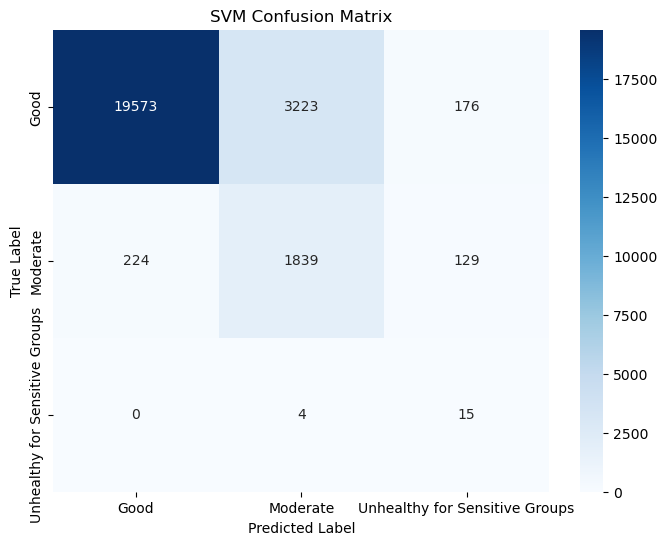

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix')
plt.show()